## Codes to draw figures

In [ ]:
# 1) import modules
import os
import re
import json
import pandas as pd
import scipy
import time
import requests
import hashlib
import csv
import random
from collections import defaultdict
import numpy as np    
import statsmodels.api as sm   
import seaborn as sns
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

## Figure S1: Distribution of conflict scores for germline conflicting variants in 40 TSGs in ClinVar.

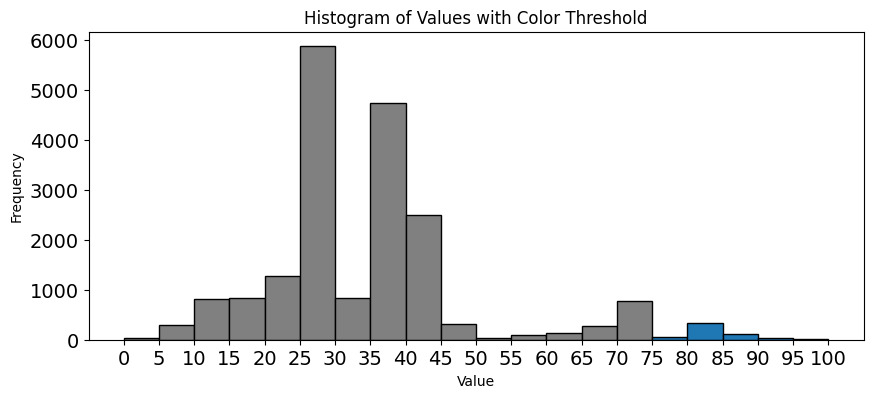

In [465]:
plt.figure(figsize=(10, 4)) 
bins = list(range(0, 105, 5))
n, bins, patches = plt.hist(conflictscore, bins=bins, edgecolor='black')
for i in range(len(patches)):
    if bins[i] < 75:
        patches[i].set_facecolor('grey')
    else:
        patches[i].set_facecolor('tab:blue')

plt.xticks(bins, fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Values with Color Threshold')


plt.savefig("Paper/conflict_scores_distribution_figureS2_9-24-25.svg", format="svg", transparent=True)
plt.show()

## Figure 3: 3D bar plot of variant counts per gene

/var/folders/84/djb4q50s33b6t8_cvx6h9src0000gn/T/ipykernel_73898/4116308066.py:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


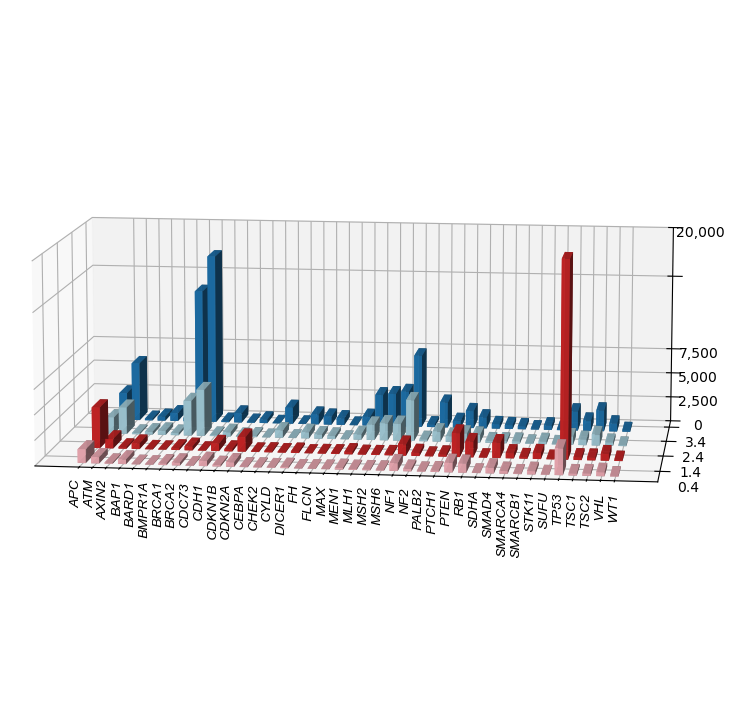

In [554]:

# Data
categories = [f'{item}' for item in dataframe3Dfig2a["Gene"]]
variables = ['Somatic unique variants', 'Somatic total events', 'Germline unique variants', 'Germline total events']
values = dataframe3Dfig2a.filter(items=['Somatic unique variants', 'Somatic total events', 'Germline unique variants', 'Germline total events']).to_numpy()

# 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos = np.meshgrid(np.arange(values.shape[0]), np.arange(values.shape[1]), indexing="ij")
x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = np.zeros_like(x_pos)

dx = dy = 0.6
dz = values.flatten()

colors = ['lightpink', 'tab:red', 'lightblue', 'tab:blue']

for i in range(4):
    ax.bar3d(x_pos[i::4], y_pos[i::4], z_pos[i::4], dx, dy, dz[i::4], color=colors[i], alpha=0.9)

ax.set_zlim(0, 20000)
#ax.set_xlabel('Genes')
#ax.set_zlabel('Count')
ax.set_xticks(np.arange(40) + 0.4)
ax.set_xticklabels(categories, rotation=90, fontname='Arial', fontsize=10, fontstyle='italic', fontweight=10)
ax.set_yticks(np.arange(4) + 0.4)
#ax.set_yticklabels(variables, fontname='Arial', fontsize=12)

ax.set_zticks([0, 2500, 5000, 7500, 15000, 20000])

ax.set_zticklabels(['0','2,500','5,000','7,500','','20,000'])



ax.view_init(elev=10, azim=-83)

ax.set_box_aspect([6, 3, 2]) # Equalize scaling of x and y axes

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


plt.tight_layout()
plt.savefig("3d_bar_plot_with_spaces_6-9-25.svg", format="svg", transparent=True, bbox_inches="tight")
plt.show()
